# Application results : Evolution of uncertainty on QualiAgro site under the different error scenarios

## For SOC stock difference $D(t)$ between two management practices scenarios (carbon farming (CF) vs baseline), under a dynamic specific baseline

Although not strictly correct, in the code we will often call the SOC stock difference $D(t)$ between two management practices scenarios "carbon_credit" for simplicity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

import csv
from scipy.integrate import odeint
import pickle

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from scipy.integrate import cumulative_trapezoid


In [2]:
#%% AMGv2 param from Clivot et al. (2019)

param={}
param['a_calcium'] = 0.0015
param['a_pH']      = 0.112
param['b_pH']      = 8.5
param['a_clay']    = 2.519*0.001
param['a_CN']      = 0.06
param['b_CN']      = 11
param['c_CN']      = 0.8
param['d_CN']      = 0.2
param['a_H']       = 0.03
param['b_H']       = 5.247
param['a_T']       = 25
param['T_ref']     = 15
param['c_T']       = 0.12
param['b_T']       = (param['a_T']-1)*np.exp(param['c_T'] *param['T_ref'] )
param['k0']        = 0.290

## Load mean inputs data and intermediate variables I and k required for the uncertainty propagation

The following dictionnaries (.npy) were created in the files generating the Monte Carlo simulations : ""generate_LUT_for_MC_all_scenario.py" and "generate_LUT_for_MC_carbon_credit.py"

- mean_t_treatment : dictionnary for which keys correspond to input values ['T', 'H', 'Clay', 'CaCO3', 'pH', 'C/N', 'I', 'QC0', 'r', 'I_CF', 'DI']. And mean_t_treatment[key] is a vector with dimenision time t containing the mean values over time. 'I_CF' corresponds to the carbon inputs humified in the carbon farming scenario, and 'DI' is the difference between the carbon inputs humified from carbon farming and baseline scenario. There is only one dictionary per treatment as mean values are not dependant of input error scenarios. 




- k_treatment : dictionnary for which keys correspond to pedoclimatic response functions modulating the mineralisation rate k and the mineralisation rate ['clay_stress', 'calcium_stress', 'pH_stress', 'CN_stress', 'T_stress', 'H_stress', 'mineralisation_rate']. And k_treatment[key] is a vector with dimension time t containing the mean values over time of each function and mineralisation rate.



In [3]:
# load mean inputs values with time t dimension_
# contain : ['T', 'H', 'Clay', 'CaCO3', 'pH', 'C/N', 'I', 'QC0', 'r', 'I_CF', 'DI']
mean_t_LEG = np.load('../inputs/mean_t_LEG.npy',allow_pickle=True).item()
mean_t_PRO = np.load('../inputs/mean_t_PRO.npy',allow_pickle=True).item()

# load peodclimatic response function modulating k with time t dimension_
# contain : ['clay_stress', 'calcium_stress', 'pH_stress', 'CN_stress', 'T_stress', 'H_stress', 'mineralisation_rate']
k_LEG = np.load('../inputs/k_LEG.npy',allow_pickle=True).item()
k_PRO = np.load('../inputs/k_PRO.npy',allow_pickle=True).item()

# duration time of the experiment studied (here 24 years for QualiAgro)
t = mean_t_LEG['T'].size


## Load vectors of sigma for all input and intermediate variables required for the uncertainty propagation, under a dynamic specific baseline

The following dictionnaries (.npy) were created in the file generating the Monte Carlo simulations : "generate_LUT_for_MC_carbon_credit.py".

With a dynamic specific baseline design, the initial conditions (initial SOC stock $C_0$ and stable/total ratio $r$) don't contribute anymore in the expression of the expected value and uncertainty of the SOC stock difference between two management practices scenario. Therefore, the error input scenarios considered only errors scenarios for carbon inputs and mineralisation rate.


There is a dictionnary per error scenarios configuration and treatment, the name of the dictionnary follows this convention : 'term1_term2_sigma_t_treatment' 



(i) The first term 'term1' corresponds to the error scenarios concerning  and input variables to compute intermediate variables I and k (carbon inputs and mineralisation rate).


- ACEO : when the scenario concerning carbon inputs uncertainty is Field-scale scenario ('ACEO' for using AgriCarbon-EO error), and 
- regstat : when the scenario concerning carbon inputs uncertainty is Large-scale scenario ('regstat' for using regional statistics error), and 

(ii) The second term 'term2' corresponds to the error scenarios concerning pedoclimatic input variables to compute the intermediate variable k i.e., the mineralisation rate. 

- k10 : when the error scenario for computing the mineralisation rate uncertainty is Field-scale scenario (k10 as in the field-scale scenario we assume a 10% relative error).
- kLS : when the error scenario for computing the mineralisation rate uncertainty is Large-scale scenario (kLS for Large-Scale error).

(iii) treatment : either 'LEG' or 'PRO'

Each dictionnary contains the sigma vector over time (dimension t) for all input variables, organised by key : ['T', 'H', 'Clay', 'pH', 'C/N', 'CaCO3', 'I', 'I_CF', 'DI']

In [4]:
dir_path = "../inputs/sigma_t/carbon_credit/"

ACEO_k10_sigma_t_LEG = np.load(dir_path + 'ACEO_k10_sigma_t_LEG.npy', allow_pickle=True).item()
ACEO_k10_sigma_t_PRO = np.load(dir_path + 'ACEO_k10_sigma_t_PRO.npy', allow_pickle=True).item()

ACEO_kLS_sigma_t_LEG = np.load(dir_path + 'ACEO_kLS_sigma_t_LEG.npy', allow_pickle=True).item()
ACEO_kLS_sigma_t_PRO = np.load(dir_path + 'ACEO_kLS_sigma_t_PRO.npy', allow_pickle=True).item()

regstat_kLS_sigma_t_LEG = np.load(dir_path + 'regstat_kLS_sigma_t_LEG.npy', allow_pickle=True).item()
regstat_kLS_sigma_t_PRO = np.load(dir_path + 'regstat_kLS_sigma_t_PRO.npy', allow_pickle=True).item()

regstat_k10_sigma_t_LEG = np.load(dir_path + 'regstat_k10_sigma_t_LEG.npy', allow_pickle=True).item()
regstat_k10_sigma_t_PRO = np.load(dir_path + 'regstat_k10_sigma_t_PRO.npy', allow_pickle=True).item()



### Organise the data concerning error input scenarios configuration

- The dictionnary config is organised by error input scenario configuration, (e.g., ACEO_k10), and will contain all the sigma's input vector for both treatments LEG and PRO.

In [5]:

configs = {
    'ACEO_k10': (ACEO_k10_sigma_t_LEG, ACEO_k10_sigma_t_PRO),
    'ACEO_kLS': (ACEO_kLS_sigma_t_LEG, ACEO_kLS_sigma_t_PRO),
    'regstat_kLS': (regstat_kLS_sigma_t_LEG, regstat_kLS_sigma_t_PRO),
    'regstat_k10': (regstat_k10_sigma_t_LEG, regstat_k10_sigma_t_PRO),
}



## Compute analytical uncertainty of mineralisation rate k (Taylor 1st order)

As in file 'uncertainty_mineralisation_sensitivity.ipynb', we compute the contribution of each pedoclimatic response function to the uncertainty of mineralisation rate k. 
As a reminder, in the paper, we show in equation 2.12 that the expression of the uncertainty of the mineralisation rate k is a sum of each pedoclimatic function uncertainty contribution.

$
\sigma_{k}^2 = k^2 \sum_{i=1}^{N} \left (\frac{ f_{i}'(x_i)}{f_{i}(x_i)} \right)^2\sigma_{x_i}^2    
$


 Here we compute each function contribution to the uncertainty. First, we compute each $\left (\frac{ f_{i}'(x_i)}{f_{i}(x_i)} \right)$, via the different eps_f() functions.

In [6]:
#%% analytical sigma k, through uncertainty propagation with Taylor 1st order

def w_fT(param, T, sigma):
    b_T = param['b_T']
    c_T = param['c_T']
    eps = abs(b_T * c_T * np.exp(-c_T*T) / (1 + b_T*np.exp(-c_T*T)))
    w = eps*sigma
    return w


def w_CaCO3(param,CACO3, sigma):
    c_m = param['a_calcium']
    eps = abs(-c_m/(1+c_m*CACO3))
    w = eps * sigma
    return w

def w_pH(param, pH, sigma):
    a_pH = param['a_pH']
    b_pH = param['b_pH']
    eps = abs(-2*a_pH*(pH-b_pH))
    w = eps * sigma
    return w

def w_CN(param,CN_ratio, sigma):
    a_CN = param['a_CN']
    b_CN = param['b_CN']    
    fp_CN = -1.6 * a_CN *(CN_ratio- b_CN)*np.exp(-a_CN *(CN_ratio-b_CN)**2)
    f = 0.8 * np.exp(-a_CN*(CN_ratio-b_CN)**2) + 0.2
    eps = abs(fp_CN/f)
    w = eps * sigma
    return w

def w_Hm(param, H, sigma):
    # In general : H = Rain - PET + irrigation
    a_H = param['a_H']
    b_H = param['b_H']
    eps = abs((a_H*b_H*np.exp(-b_H*H/1000))/(1000*(1+ a_H*np.exp(-b_H*H/1000))))
    w = eps * sigma
    return w

def w_Clay(param, sigma):
    a_Clay = param['a_clay']
    eps = abs(-a_Clay)
    w = eps*sigma
    return w

def contrib_k(param, mean_t, sigma_t):
    w_k={}
    w_k['T'] = w_fT(param, mean_t['T'], sigma_t['T'])**2
    w_k['H'] = w_Hm(param, mean_t['H'], sigma_t['H'])**2
    w_k['CaCO3'] = w_CaCO3(param, mean_t['CaCO3'], sigma_t['CaCO3'])**2
    w_k['Clay'] = w_Clay(param, sigma_t['Clay'])**2
    w_k['pH'] = w_pH(param, mean_t['pH'], sigma_t['pH'])**2
    w_k['C/N'] = w_CN(param, mean_t['C/N'], sigma_t['C/N'])**2
    return w_k
    



In [7]:
# we compute sigma k, first the contribution of each stress function w, and then var k (sigma2), finally sigma k

# dictionary that will store the uncertainty of mineralisation rate
sigma_stress = {}

for name, (sigma_LEG, sigma_PRO) in configs.items():
    w_LEG = contrib_k(param, mean_t_LEG, sigma_LEG)
    w_PRO = contrib_k(param, mean_t_PRO, sigma_PRO)

    sigma2_LEG = k_LEG['mineralisation_rate']**2 * sum(
        w_LEG[k] for k in ['T', 'H', 'CaCO3', 'Clay', 'pH', 'C/N']
    )
    sigma2_PRO = k_PRO['mineralisation_rate']**2 * sum(
        w_PRO[k] for k in ['T', 'H', 'CaCO3', 'Clay', 'pH', 'C/N']
    )

    sigma_stress[f'{name}_LEG'] = {'mineralisation_rate': np.sqrt(sigma2_LEG)}
    sigma_stress[f'{name}_PRO'] = {'mineralisation_rate': np.sqrt(sigma2_PRO)}


## Load all Monte Carlo simulations

The Monte Carlo simulations are called after the error scenario configuration and the treatment as the input sigma's vectors, but with the mention AMG_LUT.

The Monte Carlo simulations are generated by running the file "generate_LUT_for_MC_carbon_credit.py", that will be stored in the repertory '../outputs/LUT_MC/carbon_credit/AMG_LUT/'.




In [8]:
## Load only the simulations with sample size n=10⁵
n = 100000

## First I get all the names of the dictionary files :

dir_path = "../outputs/LUT_MC/carbon_credit/"

names = [
    'AMG_ACEO_k10_LUT_LEG',
    'AMG_ACEO_k10_LUT_PRO',
    'AMG_ACEO_kLS_LUT_LEG',
    'AMG_ACEO_kLS_LUT_PRO',
    'AMG_regstat_kLS_LUT_LEG',
    'AMG_regstat_kLS_LUT_PRO',
    'AMG_regstat_k10_LUT_LEG',
    'AMG_regstat_k10_LUT_PRO',
]

## Now that I have all names I load them all here and called them with the same name as the .npy file

for name in names:
    globals()[name] = np.load(
        f'{dir_path}{name}_n_{n}.npy',
        allow_pickle=True
    ).item()


# Analytical Stationary case : uncertainty propagation (equations 2.16 - 2.18 and 3.1)
- The first function computes $\mu_{D(t)}$, $\sigma_{D(t)}$ and $\sigma²_{D(t)}$
- The second function computes $t_{min}$ which is the minimum period required to estimate a satistical significant positif SOC stock difference between two management practices, i.e., $\mu_{D(t)} - z \sigma_{D(t)} > 0$, wth z the critical value given the confidence interval required (e.g., z=3 for a 99% confidence interval)

In [9]:
## We compute the expectation value E and the uncertainty (sigma and variance) :
## - of the SOC stock difference D(t) beween two management practices scenarios
## under a dynamic specific baseline


"""
We return a dictionnary, containing : 
- the vector of expectation value E over time : result['E']
- the vector of uncertainty over time : result['sigma']
- the vector of the variance over time : result['var']

"""

def E_sigma_D_stationnary(means_input, stress, sigma_input, sigma_stress, time):

    ## As we are in the stationary case, we take the mean value of the intermediate variables : 

    # Mineralisation rate k
    mu_k = np.mean(stress['mineralisation_rate'])
    sigma_k = np.mean(sigma_stress['mineralisation_rate'])

    # Carbon inputs humified I
    mu_I = np.mean(means_input['DI'])
    sigma_I = np.mean(sigma_input['DI'])
   
    # vector time of the simulation
    t = np.arange(0,time, 1)
    
    # coefficient defined in eq. (2.17)
    a_k = mu_k - 0.5 * sigma_k**2
    b_k = mu_k - sigma_k**2
    d_k = mu_k - (3/2)*sigma_k**2
    
    ## Solution of the system of the differential equations :
    # E[D(t)]
    E_D = (mu_I/a_k)*(1-np.exp(-a_k*t)) 
    
    # Var[D(t)]
    Var_D = - E_D**2 + np.exp(-2*b_k*t) * (  (2*mu_I**2/a_k) *((1-np.exp(d_k*t))/d_k  
             +(np.exp(2*b_k*t) -1)/(2*b_k)) + (sigma_I**2 *(np.exp(2*b_k*t)-1))/(2*b_k))   
    
    result={}
    result['E'] = E_D
    result['sigma'] = np.sqrt(Var_D)
    result['var'] = Var_D

    return result

# We compute t_min, which represent the minimum period required to have :
# a statistical significant positive SOC stock difference btween two management practices
def compute_t_min(means_input, stress, sigma_input, sigma_stress, z):
    
    mu_k = np.mean(stress['mineralisation_rate'])
    mu_I = np.mean(means_input['DI'])
    sigma_I = np.mean(sigma_input['DI'])
    a = mu_I**2 / mu_k**2
    b =( z**2 * sigma_I**2 )/ (2*mu_k)
    print("1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) :", mu_I**2 != z**2 * sigma_I**2 / (2*mu_k))
    print("2nd condition mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2 :", mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2)

    print("max err relative DI to ensure 2nds conditions :", np.sqrt(2/(z**2 *mu_k)))
    print('err_rel DI:', sigma_I/mu_I)
    t_min = (1/mu_k) * np.log((a+b)/(a-b))
    return t_min

# Analytical Non-stationary case : uncertainty propagation (equations 2.16 - 2.18)

In the non-stationary case, the system of differential equations 2.16 is solved numerically with the odeint function from the python library scipy.integrate. The solutions of the system are 4 intermediate variables noted M1(t), M2(t), M11(t) and N11(t),  that allow to compute the expectation value and standard deviation (or variance) of the target variable : absolut SOC stock $C(t)$, the temporal SOC stock change $\Delta C(t)$ and the difference of SOC stock between two management practices $D(t)$ (see eq. 2.18).

In the case of the SOC stock difference, the initial conditions are null.

In [10]:
#%% Solve equa diff system for active SOC stock uncertainty

# We define the system of differential equations (2.16)
def AMG_system_D_odeint(Y,t, mu_I_t, sigma_I_t, mu_k_t, sigma_k_t, a_k_t, b_k_t, d_k_t):
    M1, M2 = Y
    t =int(t)
    dM1  = -a_k_t[t]*M1  +  mu_I_t[t]
    dM2  = -2*b_k_t[t]*M2 + 2*mu_I_t[t]*M1 + sigma_I_t[t]**2

    return [dM1, dM2]

# We define the coefficients of the systems of differential equations (2.16)
def coeffs(means_input, stress, sigma_input, sigma_stress) :

    mu_k_t = stress['mineralisation_rate']
    sigma_k_t = sigma_stress['mineralisation_rate']
    
    mu_I_t = means_input['DI']
    sigma_I_t = sigma_input['DI']
    
    a_k_t = mu_k_t - 0.5*(sigma_k_t*sigma_k_t)
    b_k_t = mu_k_t - (sigma_k_t*sigma_k_t)
    d_k_t = 2*b_k_t - a_k_t
    
    return mu_I_t, sigma_I_t, mu_k_t, sigma_k_t, a_k_t, b_k_t, d_k_t, 



# We compute the expectation value and uncertainty of the absolute SOC stock C(t) based on the solution of the system
# see eq. (2.18)
def E_sigma_QC_vari_odeint(sol_odeint_QC):
    
    # we get the solutions of the system of differential equations (2.16)
    M1 = sol_odeint_QC[:,0]
    M2 = sol_odeint_QC[:,1]
    
    # we compute the variance of the SOC stock difference between two management practices
    Var_D =  M2 - M1*M1
    
    # we store the results in a dictionary
    result = {}
    result['E']= M1
    result['sigma']=np.sqrt(Var_D)
    result['var']=Var_D

    return result


# Application

We define here the critical value z, that determine the confidence interval considered. We need it to compute the t_min values, and after to plot the envelope $\mu \pm z \sigma$ in the timeseries plots.

In [39]:
z = 2 # critical value for confidence interval, required to compute t_min


### Stationary case

In [40]:
# Dictionaries that will contain the expectations values and uncertainty (sigma and var)
# For the SOC stock difference D(t)
# keys are the error scenarios configurations

D_const_analytic_LEG={}
D_const_analytic_PRO={}

# Dictionaries that contain the values of t_min
# keys are the error scenarios configurations
t_min_LEG = {}
t_min_PRO = {}


for name, (sigma_LEG, sigma_PRO) in configs.items():
    D_const_analytic_LEG[f'{name}_LEG'] = E_sigma_D_stationnary(mean_t_LEG, k_LEG, sigma_LEG, sigma_stress[f'{name}_LEG'], t)

    D_const_analytic_PRO[f'{name}_PRO'] = E_sigma_D_stationnary(mean_t_PRO, k_PRO, sigma_PRO, sigma_stress[f'{name}_PRO'], t)
    print(f'{name}_LEG')
    t_min_LEG[f'{name}_LEG'] = compute_t_min(mean_t_LEG, k_LEG, sigma_LEG, sigma_stress[f'{name}_LEG'], z)
    print(f'{name}_PRO')
    t_min_PRO[f'{name}_PRO'] = compute_t_min(mean_t_PRO, k_PRO, sigma_PRO, sigma_stress[f'{name}_PRO'],z)

ACEO_k10_LEG
1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) : True
2nd condition mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2 : True
max err relative DI to ensure 2nds conditions : 2.644689962278821
err_rel DI: 0.9061387915404631
ACEO_k10_PRO
1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) : True
2nd condition mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2 : True
max err relative DI to ensure 2nds conditions : 2.54640187396544
err_rel DI: 1.0506753950636403
ACEO_kLS_LEG
1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) : True
2nd condition mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2 : True
max err relative DI to ensure 2nds conditions : 2.644689962278821
err_rel DI: 0.9061387915404631
ACEO_kLS_PRO
1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) : True
2nd condition mu_I**2 >= (z**2 *mu_k*sigma_I**2)/2 : True
max err relative DI to ensure 2nds conditions : 2.54640187396544
err_rel DI: 1.0506753950636403
regstat_kLS_LEG
1st condition mu_I**2 != z**2 * sigma_I**2 / (2*mu_k) : True
2nd condi

### Non stationary case

In [41]:
# the time vector on which the system of differential equation will be solved 
t_solve = np.arange(t)

# the initial conditions of the system
Y0 = [0,0]

# the coefficients of the system
coeffs_LEG = {}
coeffs_PRO = {}

#the solution of the system
sol_odeint_D_LEG ={}
sol_odeint_D_PRO ={}

# the vectors of the expected and uncertaintis values of the SOC variables
# based on the solutions of the system :
D_vari_t_analytic_LEG={}
D_vari_t_analytic_PRO={}

for name, (sigma_LEG, sigma_PRO) in configs.items():
    
    # we compute the coefficients of the system
    coeffs_LEG[f'{name}_LEG'] = coeffs(mean_t_LEG, k_LEG, sigma_LEG, sigma_stress[f'{name}_LEG'])
    coeffs_PRO[f'{name}_PRO'] = coeffs(mean_t_PRO, k_PRO, sigma_PRO, sigma_stress[f'{name}_PRO'])

    # we apply the numerical integration function odeint to our system of differential equations
    sol_odeint_D_PRO[f'{name}_PRO'] = odeint(
    AMG_system_D_odeint,
    Y0,
    t_solve,
    args=coeffs_PRO[f'{name}_PRO']
)

    sol_odeint_D_LEG[f'{name}_LEG'] = odeint(
    AMG_system_D_odeint,
    Y0,
    t_solve,
    args=coeffs_LEG[f'{name}_LEG']
)
    
    # Based on the solutions of the system of differential equations, 
    # we compute the expectation value and the uncertainty (sigma and var) :
    # For the absolute SOC stock D(t)
    D_vari_t_analytic_LEG[f'{name}_LEG'] = E_sigma_QC_vari_odeint(sol_odeint_D_LEG[f'{name}_LEG'])
    D_vari_t_analytic_PRO[f'{name}_PRO'] = E_sigma_QC_vari_odeint(sol_odeint_D_PRO[f'{name}_PRO'])






### Get LUT for Monte Carlo

In [42]:
# to get the mean of SOC stock difference and its associated uncertainty based on MONTE CARLO

def get_E_sigma_LUT(LUT):
    result = {}
    result['E'] = np.mean(LUT['D'], axis=1)
    result['sigma'] = np.std(LUT['D'], axis=1)
    return result

# dictionaries that will store the results from MONTE CARLO simulations 
D_LUT_LEG = {}
D_LUT_PRO = {}

# we loop on the error scenario configurations names:
for name, (sigma_LEG, sigma_PRO) in configs.items():
    D_LUT_LEG[f'{name}_LEG'] = get_E_sigma_LUT(globals()[f'AMG_{name}_LUT_LEG'])
    D_LUT_PRO[f'{name}_PRO'] = get_E_sigma_LUT(globals()[f'AMG_{name}_LUT_PRO'])


# Plot figures :  Timeseries of SOC stock (t) difference between two management practices and its uncertainty, under a dynamic specific baseline


We plot a graphic for each error scenario configuration, for each treatment (LEG and PRO). We plot the evolution of the expected SOC stock difference between two management practices $\mu_{D(t)}$ with its envelope $\mu_{D(t)} \pm z \sigma_{D(t)}$, under a dynamic specific baseline design. With z the critical value. The critical value is defined above in the begining of "Application" section, since it is required to compute t_min values.


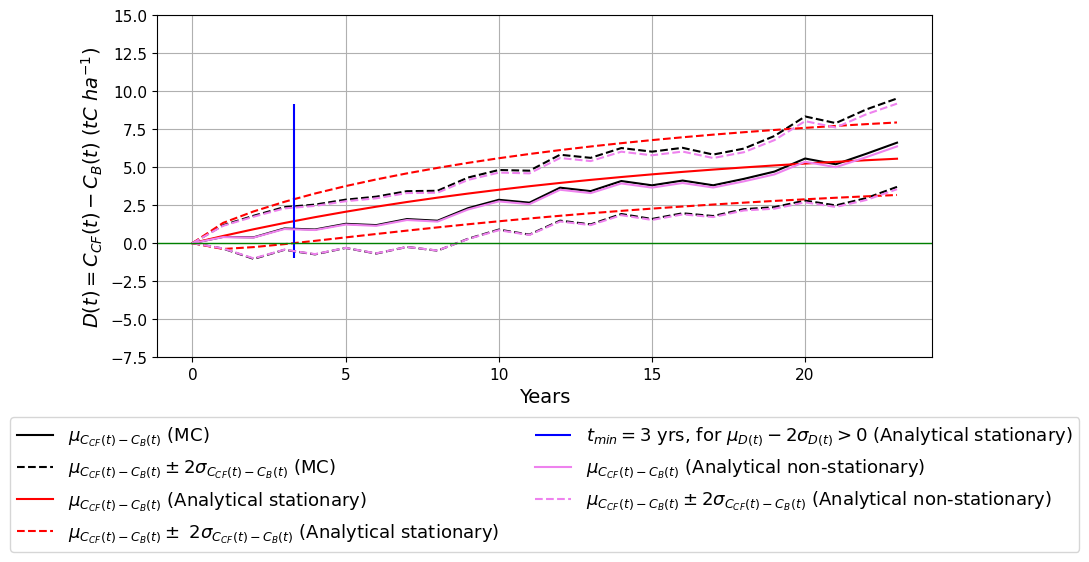

/tmp/ipykernel_80246/3578727659.py:116: RuntimeWarning: invalid value encountered in divide
  sigma_rel_LEG[f'{name}_LEG']['stationary'] = D_const_analytic_LEG[f'{name}_LEG']['sigma']/D_const_analytic_LEG[f'{name}_LEG']['E']
/tmp/ipykernel_80246/3578727659.py:117: RuntimeWarning: invalid value encountered in divide
  sigma_rel_LEG[f'{name}_LEG']['vari'] = D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']/D_vari_t_analytic_LEG[f'{name}_LEG']['E']


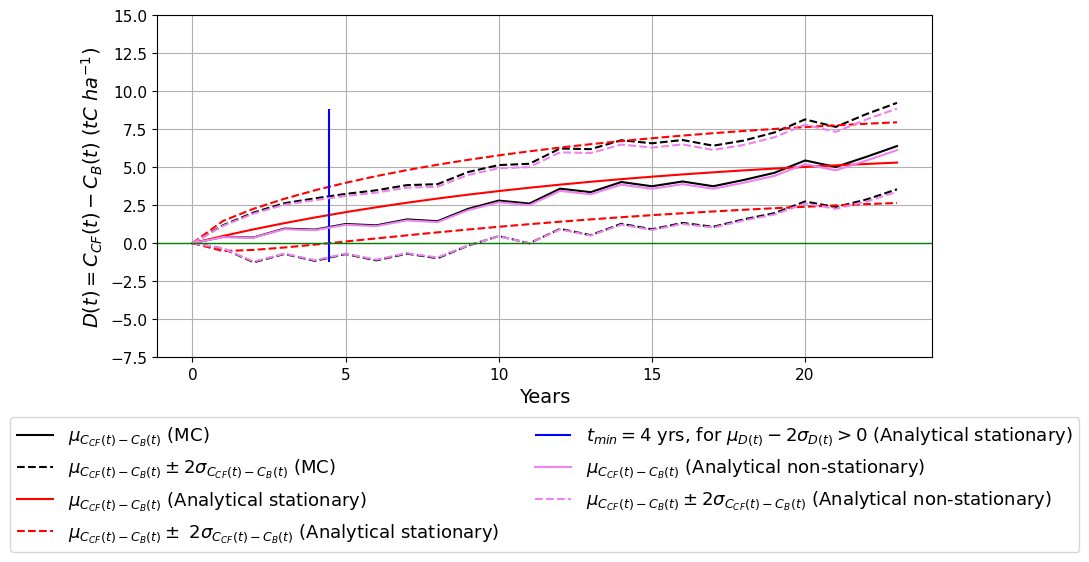

/tmp/ipykernel_80246/3578727659.py:200: RuntimeWarning: invalid value encountered in divide
  sigma_rel_PRO[f'{name}_PRO']['stationary'] = D_const_analytic_PRO[f'{name}_PRO']['sigma']/D_const_analytic_PRO[f'{name}_PRO']['E']
/tmp/ipykernel_80246/3578727659.py:201: RuntimeWarning: invalid value encountered in divide
  sigma_rel_PRO[f'{name}_PRO']['vari'] = D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']/D_vari_t_analytic_PRO[f'{name}_PRO']['E']


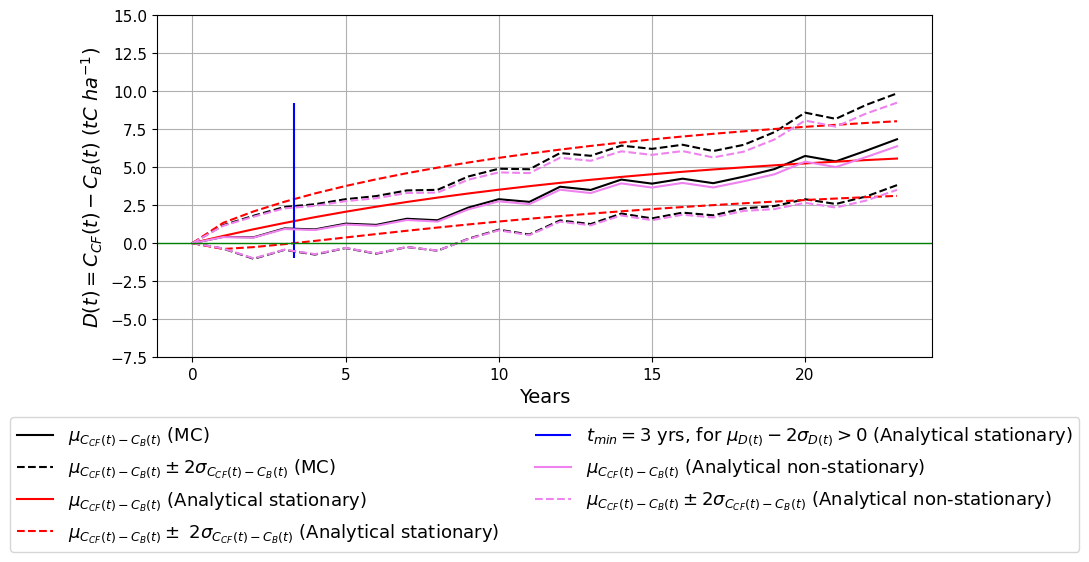

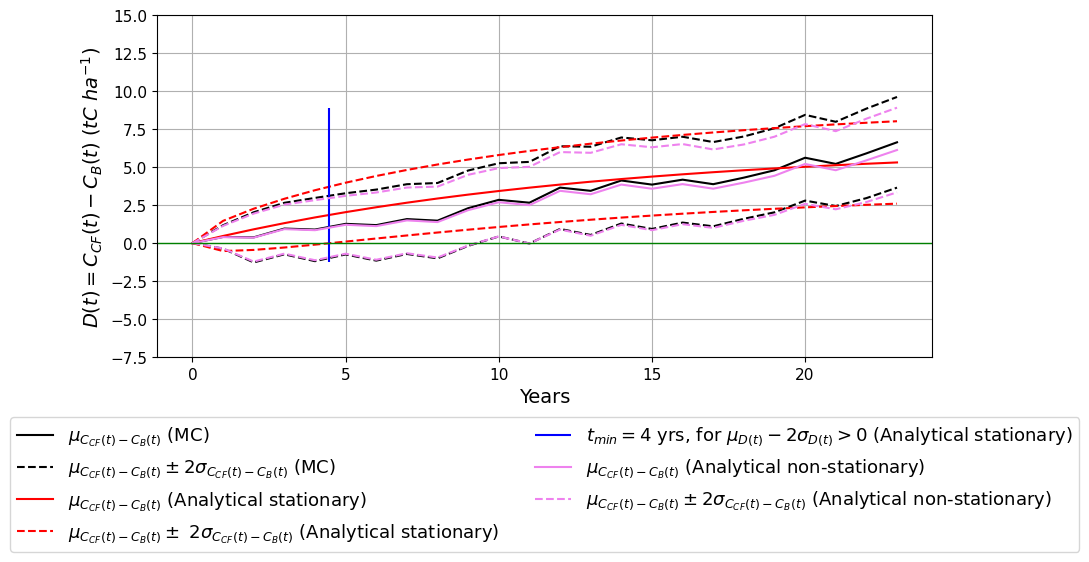

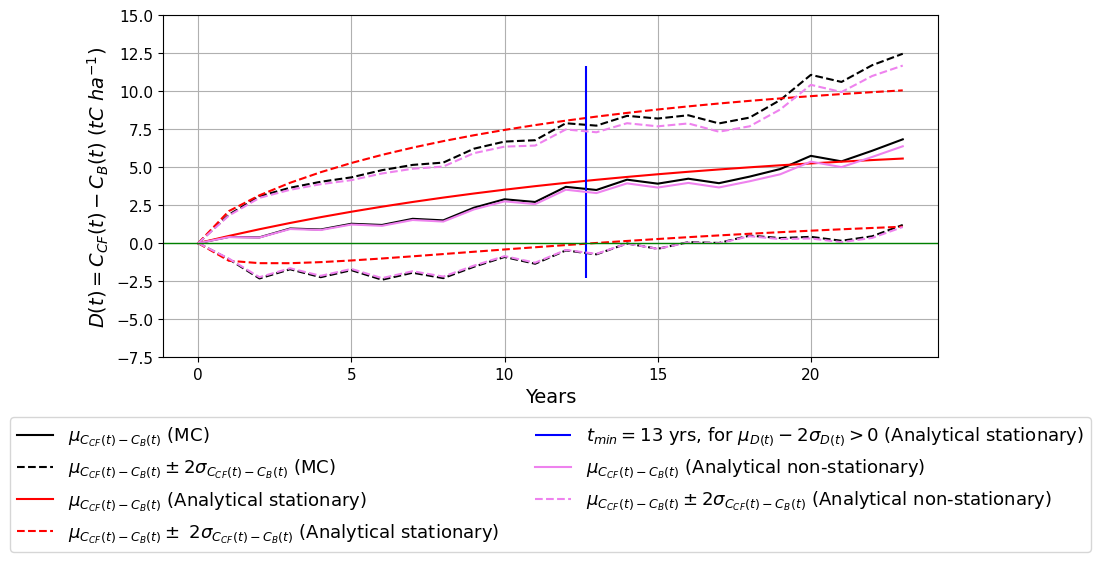

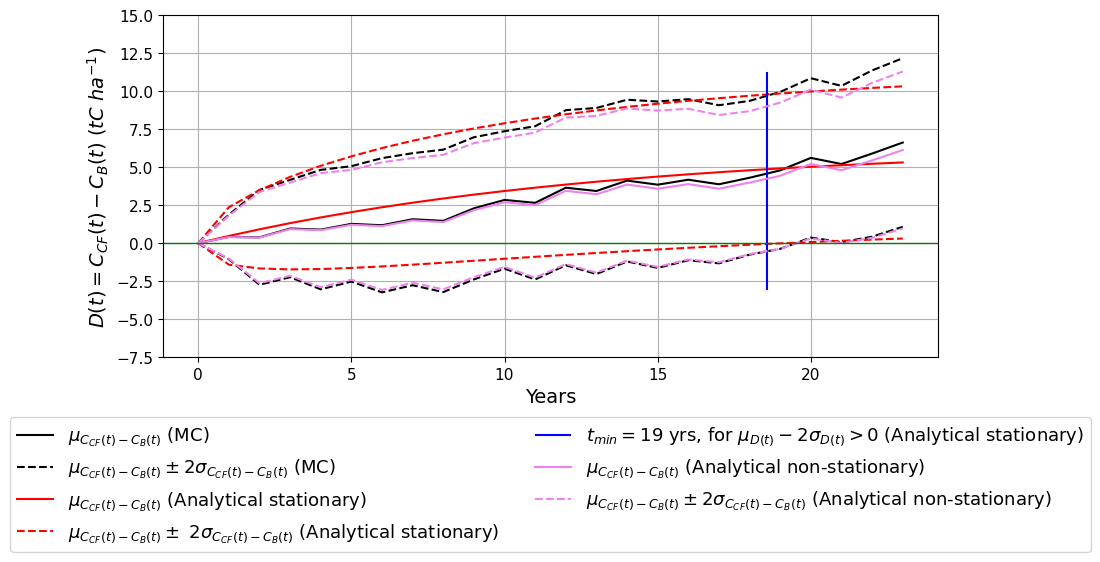

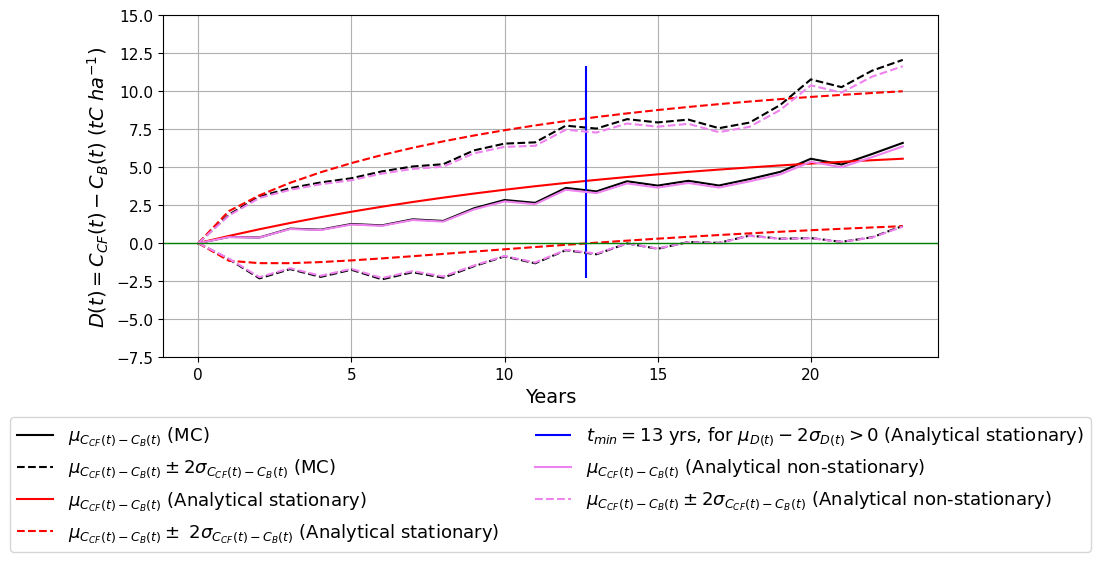

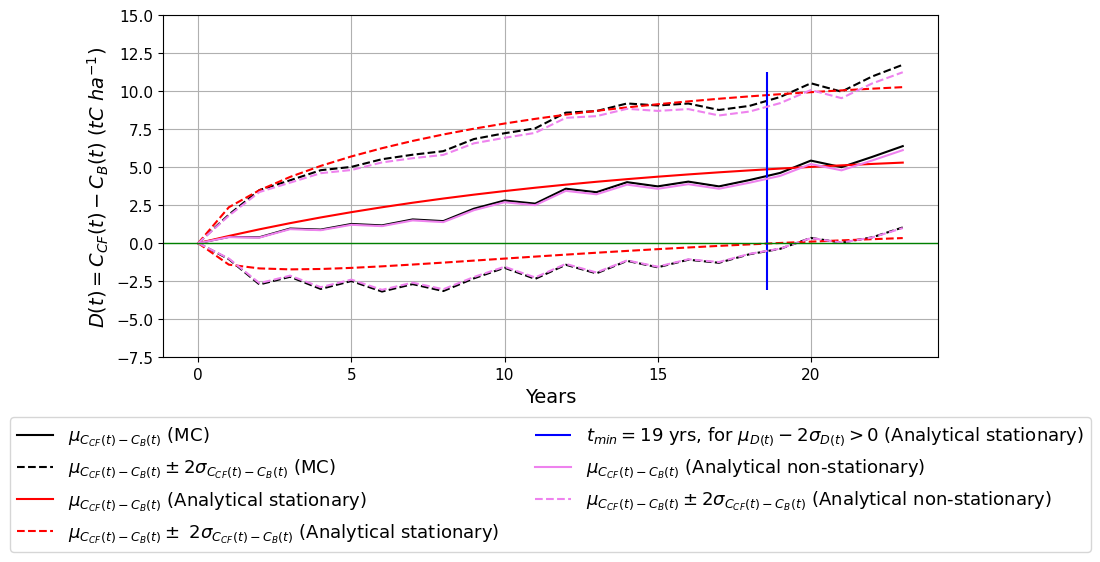

In [43]:
## Path to save figures, commented for now
dir_path_figures = '../figures/timeseries/carbon_credit/'
# Create the repertory if needed
dir_path_figures = Path(dir_path_figures)
dir_path_figures.mkdir(parents=True, exist_ok=True)

## Path to save the dictionary containing the results of the analytical uncertainty propagation, 
    ## both stationary and non-stationary
dir_path_dict = '../outputs/result_analytical_method/carbon_credit/'
# Create the repertory if needed
dir_path_dict = Path(dir_path_dict)
dir_path_dict.mkdir(parents=True, exist_ok=True)
    
# dictionaries that will store the uncertainties over time
# relative uncertainty
sigma_rel_LEG={}
sigma_rel_PRO={}

# absolute uncertainty
sigma_LEG={}
sigma_PRO={}

# dictionaries that will store the metric mu - z*sigma, 
# that is the inferior born of the envelope mu +- z*sigma
# which is used for the estimation of t_min
born_inf_LEG ={}
born_inf_PRO = {}

# to define the size of all texts in plot
plt.rcParams.update({
    "font.size": 12,          # general fontsize
    "axes.labelsize": 14,     # xlabel / ylabel
    "axes.titlesize": 16,     # title
    "legend.fontsize": 13,    # legend
    "xtick.labelsize": 11,    # X graduations 
    "ytick.labelsize": 11,    # Y graduations
})

# we loop over all the error scenario configurations
for name, (_, _) in configs.items():
    
    ## LEG
    
    # we check if t_min is a real value 
    if np.isnan(t_min_LEG[f'{name}_LEG']):
        label_vline=r'$t_{min}=$ No real value'
        idx_safe=99999
    # if t_min exist and is real, we plot its value
    else :
        idx_safe = int(t_min_LEG[f'{name}_LEG'])
        label_vline = (
        rf"$t_{{min}} = {t_min_LEG[f'{name}_LEG']:.0f}$ yrs, for $\mu_{{D(t)}}-{z}\sigma_{{D(t)}}>0$ (Analytical stationary)")


    plt.figure(figsize=(10, 6))

    # To plot the Monte Carlo solutions over time
    plt.plot(D_LUT_LEG[f'{name}_LEG']['E'],
         color='black', label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (MC)')
    plt.plot(D_LUT_LEG[f'{name}_LEG']['E'] + z * D_LUT_LEG[f'{name}_LEG']['sigma'],
         color='black', linestyle='--', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$'+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (MC)')
    plt.plot(D_LUT_LEG[f'{name}_LEG']['E'] - z * D_LUT_LEG[f'{name}_LEG']['sigma'],
         color='black', linestyle='--')
    
    # To plot the analytical stationary solutions over time
    plt.plot(D_const_analytic_LEG[f'{name}_LEG']['E'], color='red', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (Analytical stationary)')
    plt.plot(D_const_analytic_LEG[f'{name}_LEG']['E'] + z * D_const_analytic_LEG[f'{name}_LEG']['sigma'],
             color='red', linestyle='--', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$ '+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (Analytical stationary)')
    plt.plot(D_const_analytic_LEG[f'{name}_LEG']['E'] - z * D_const_analytic_LEG[f'{name}_LEG']['sigma'], 
             color='red', linestyle='--')
    
    # If t_min value is within the project duration (t_min<24 years)
    # we plot a vertical line to represent it on the graphic
    if idx_safe<24:
        plt.vlines(t_min_LEG[f'{name}_LEG'],
                   np.min(D_vari_t_analytic_LEG[f'{name}_LEG']['E']- z* D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']),
                   np.max(D_vari_t_analytic_LEG[f'{name}_LEG']['E']+ z* D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']), 
                   linestyle='-', color='blue',label=label_vline)
    else :

        plt.vlines([],[],[],linestyle='-', color='blue',label=label_vline)

    # To plot the analytical non-stationary ("vari") solutions over time
    plt.plot(D_vari_t_analytic_LEG[f'{name}_LEG']['E'], color='violet', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (Analytical non-stationary)')
    plt.plot(D_vari_t_analytic_LEG[f'{name}_LEG']['E'] + z * D_vari_t_analytic_LEG[f'{name}_LEG']['sigma'],
             color='violet', linestyle='--', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$'+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (Analytical non-stationary)')
    plt.plot(D_vari_t_analytic_LEG[f'{name}_LEG']['E'] - z * D_vari_t_analytic_LEG[f'{name}_LEG']['sigma'],
             color='violet', linestyle='--')

    plt.xlabel("Years")
    plt.ylabel("$D(t) = C_{CF}(t) - C_{B}(t)$ ($tC~ha^{-1}$)")
    plt.grid(True)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2
    )
    plt.ylim((-7.5, 15))
    plt.axhline(0, linestyle='solid', linewidth=1, color='green')

    plt.subplots_adjust(bottom=0.31)

    plt.savefig(dir_path_figures / f'carbon_credit_{name}_LEG_IC_{z}.png',bbox_inches="tight", dpi=300)
    plt.show()
    
    # We save the uncertainty estimated (the sigma's vector) per error scenario configuration,
    # in a dictionary, organised by the analytical methods, either stationary or non-stationary called 'vari'
    
    # the relative uncertainty    
    sigma_rel_LEG[f'{name}_LEG']={}
    sigma_rel_LEG[f'{name}_LEG']['stationary'] = D_const_analytic_LEG[f'{name}_LEG']['sigma']/D_const_analytic_LEG[f'{name}_LEG']['E']
    sigma_rel_LEG[f'{name}_LEG']['vari'] = D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']/D_vari_t_analytic_LEG[f'{name}_LEG']['E']

    # the absolute uncertainty
    sigma_LEG[f'{name}_LEG']={}
    sigma_LEG[f'{name}_LEG']['stationary'] = D_const_analytic_LEG[f'{name}_LEG']['sigma']
    sigma_LEG[f'{name}_LEG']['vari'] = D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']

    # the inferior born mu-Z*sigma :    
    born_inf_LEG[f'{name}_LEG']={}
    born_inf_LEG[f'{name}_LEG']['stationary'] = - z *D_const_analytic_LEG[f'{name}_LEG']['sigma'] + D_const_analytic_LEG[f'{name}_LEG']['E']
    born_inf_LEG[f'{name}_LEG']['vari'] = -z*D_vari_t_analytic_LEG[f'{name}_LEG']['sigma']+D_vari_t_analytic_LEG[f'{name}_LEG']['E']
    
    ## PRO
    
    # we check if t_min is a real value
    if np.isnan(t_min_PRO[f'{name}_PRO']):
        label_vline=r'$t_{min}=$ No real value'
    # if t_min exist and is real, we plot its value
    else :
        idx_safe = int(t_min_PRO[f'{name}_PRO'])
        label_vline = (
        rf"$t_{{min}} = {t_min_PRO[f'{name}_PRO']:.0f}$ yrs, for $\mu_{{D(t)}}-{z}\sigma_{{D(t)}}>0$ (Analytical stationary)")


    plt.figure(figsize=(10, 6))

    # To plot the Monte Carlo solutions over time
    plt.plot(D_LUT_PRO[f'{name}_PRO']['E'],
         color='black', label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (MC)')
    plt.plot(D_LUT_PRO[f'{name}_PRO']['E'] + z * D_LUT_PRO[f'{name}_PRO']['sigma'],
         color='black', linestyle='--', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$'+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (MC)')
    plt.plot(D_LUT_PRO[f'{name}_PRO']['E'] - z * D_LUT_PRO[f'{name}_PRO']['sigma'],
         color='black', linestyle='--')
             
    # To plot the analytical stationary solutions over time
    plt.plot(D_const_analytic_PRO[f'{name}_PRO']['E'], color='red', label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (Analytical stationary)')
    plt.plot(D_const_analytic_PRO[f'{name}_PRO']['E'] + z * D_const_analytic_PRO[f'{name}_PRO']['sigma'],
             color='red', linestyle='--', label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$ '+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (Analytical stationary)')
    plt.plot(D_const_analytic_PRO[f'{name}_PRO']['E'] - z * D_const_analytic_PRO[f'{name}_PRO']['sigma'], color='red',
             linestyle='--')
    
    # If t_min value is within the project duration (t_min<24 years)
    # we plot a vertical line to represent it on the graphic
    if idx_safe<24 :
        plt.vlines(t_min_PRO[f'{name}_PRO'],
                   np.min(D_vari_t_analytic_PRO[f'{name}_PRO']['E']-z*D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']),
                   np.max(D_vari_t_analytic_PRO[f'{name}_PRO']['E']+z*D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']), 
                   linestyle='-', color='blue',label=label_vline)
    else:
        plt.vlines([],[],[],linestyle='-', color='blue',label=label_vline)

    # To plot the analytical non-stationary ("vari") solutions over time
    plt.plot(D_vari_t_analytic_PRO[f'{name}_PRO']['E'], color='violet', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)}$ (Analytical non-stationary)')
    plt.plot(D_vari_t_analytic_PRO[f'{name}_PRO']['E'] + z * D_vari_t_analytic_PRO[f'{name}_PRO']['sigma'],
             color='violet', linestyle='--', 
             label='$\mu_{C_{CF}(t)-C_{B}(t)} \pm$'+str(z)+'$\sigma_{C_{CF}(t)-C_{B}(t)}$ (Analytical non-stationary)')
    plt.plot(D_vari_t_analytic_PRO[f'{name}_PRO']['E'] - z * D_vari_t_analytic_PRO[f'{name}_PRO']['sigma'], 
             color='violet', linestyle='--')

    plt.xlabel("Years")
    plt.ylabel("$D(t) = C_{CF}(t) - C_{B}(t)$ ($tC~ha^{-1}$)")
    plt.grid(True)
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2
    )
    plt.ylim((-7.5, 15))
    plt.axhline(0, linestyle='solid', linewidth=1, color='green')
    plt.subplots_adjust(bottom=0.31)

    plt.savefig(dir_path_figures / f'carbon_credit_{name}_PRO_IC_{z}.png',bbox_inches="tight", dpi=300)

    plt.show()
    

    # We save the uncertainty estimated (the sigma's vector) per error scenario configuration,
    # in a dictionary, organised by the analytical methods, either stationary or non-stationary called 'vari'
    
    # the relative uncertainty
    sigma_rel_PRO[f'{name}_PRO']={}
    sigma_rel_PRO[f'{name}_PRO']['stationary'] = D_const_analytic_PRO[f'{name}_PRO']['sigma']/D_const_analytic_PRO[f'{name}_PRO']['E']
    sigma_rel_PRO[f'{name}_PRO']['vari'] = D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']/D_vari_t_analytic_PRO[f'{name}_PRO']['E']

    # the absolute uncertainty
    sigma_PRO[f'{name}_PRO']={}
    sigma_PRO[f'{name}_PRO']['stationary'] = D_const_analytic_PRO[f'{name}_PRO']['sigma']
    sigma_PRO[f'{name}_PRO']['vari'] = D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']
    
    # the inferior born mu-Z*sigma :
    born_inf_PRO[f'{name}_PRO']={}
    born_inf_PRO[f'{name}_PRO']['stationary'] = - z *D_const_analytic_PRO[f'{name}_PRO']['sigma'] + D_const_analytic_PRO[f'{name}_PRO']['E']
    born_inf_PRO[f'{name}_PRO']['vari'] = -z*D_vari_t_analytic_PRO[f'{name}_PRO']['sigma']+D_vari_t_analytic_PRO[f'{name}_PRO']['E']

        

# We save all dictionaries in pickles
with open(dir_path_dict/f"sigma_D_PRO_IC_{z}.pkl", "wb") as f:
    pickle.dump(sigma_PRO, f)

with open(dir_path_dict/f"sigma_D_rel_PRO_IC_{z}.pkl", "wb") as f:
    pickle.dump(sigma_rel_PRO, f)

with open(dir_path_dict/f"sigma_D_LEG_IC_{z}.pkl", "wb") as f:
    pickle.dump(sigma_LEG, f)

with open(dir_path_dict/f"sigma_D_rel_LEG_IC_{z}.pkl", "wb") as f:
    pickle.dump(sigma_rel_LEG, f)

with open(dir_path_dict/f"born_inf_D_PRO_IC_{z}.pkl", "wb") as f:
    pickle.dump(born_inf_PRO, f)

with open(dir_path_dict/f"born_inf_D_LEG_IC_{z}.pkl", "wb") as f:
    pickle.dump(born_inf_LEG, f)



## Function to plot uncertainty evolution

In [44]:
def plot_sigma(
    sigma_dict,
    key='stationary',
    dir_path='figures',
    title='Evolution of uncertainty',
    filename='plot_sigma.png',
    ylabel=None,
    label_map=None,
    color_map_dict=None,
    style_map_dict=None,
    style_label_map=None
):

    
    # Create the repertory if necessary
    dir_path = Path(dir_path)
    dir_path.mkdir(parents=True, exist_ok=True)
    
    
    fig, ax = plt.subplots(figsize=(10,5))
    
    # Plot all curves
    for name in sigma_dict.keys():
        sigmaI = name.split('_')[0]
        sigmak = name.split('_')[1]
        label_name = label_map.get(sigmaI) if label_map else sigmaI
        ax.plot(
            sigma_dict[name][key],
            color=color_map_dict.get(sigmaI, 'black') if color_map_dict else 'black',
            linestyle=style_map_dict.get(sigmak, 'solid') if style_map_dict else 'solid'
        )
    
    # Horizontal line at 0
    ax.axhline(0, linestyle='solid', linewidth=1, color='green', alpha=0.5)
    
    # Title and labels
    #ax.set_title(title)
    ax.set_xlabel('Years')
    ax.set_ylabel(ylabel)
    
    # Grid
    ax.grid(True, linestyle='--', alpha=0.5)
    

    # -------------------
    # Legend to add text
    text_proxy = Line2D([], [], linestyle='none')

    legend_text = ax.legend(
        [text_proxy],
        ['No contribution of initialisation'],
        loc='upper left',
        bbox_to_anchor=(1.02, 1),  
        frameon=True,
        borderaxespad=0
    )
    ax.add_artist(legend_text)

    
    # -------------------
    # Legend for colors (sigma I)
    if color_map_dict and label_map:
        color_proxies = [Line2D([0],[0], color=color_map_dict[k], lw=2) for k in color_map_dict.keys()]
        color_labels  = [label_map[k] for k in color_map_dict.keys()]
        legend1 = ax.legend(color_proxies, color_labels, title='Errors on inputs for $I$',
                            loc='upper left', bbox_to_anchor=(1.02, 0.7), borderaxespad=0)
        ax.add_artist(legend1)
    
    # Legend for linestyle (sigma k)
    if style_map_dict:
        style_proxies = [Line2D([0],[0], color='black', lw=2, linestyle=style_map_dict[k]) for k in style_map_dict.keys()]
        style_labels  = [style_label_map[k] for k in style_label_map.keys()]
        ax.legend(style_proxies, style_labels, title='Errors on inputs for $k$',
                  loc='upper left', bbox_to_anchor=(1.02, 0.3), borderaxespad=0)
    
    #Adjust legend at righ
    fig.subplots_adjust(right=0.7, top=0.82)
    
    # Save
    fig.savefig(dir_path / filename, dpi=300, bbox_inches='tight')
    #plt.close(fig)


## Absolute uncertainty of SOC stock difference $D(t)$ between two management practices, under a dynamic specific baseline

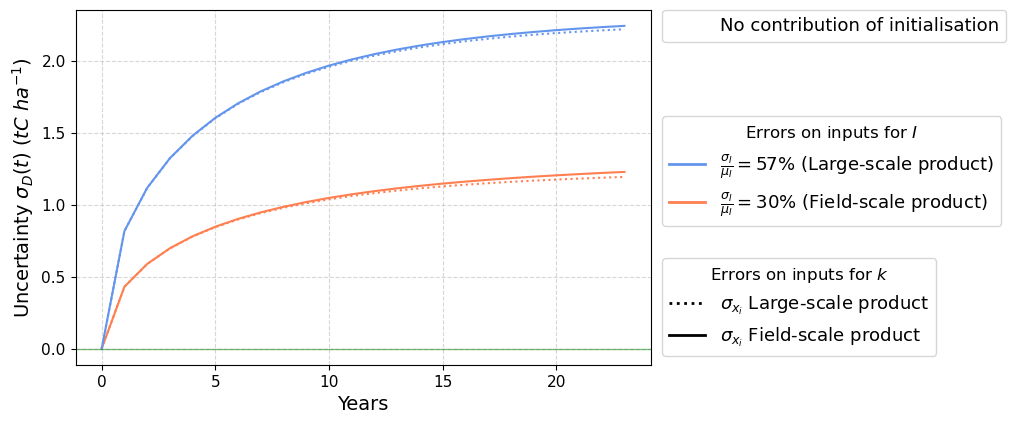

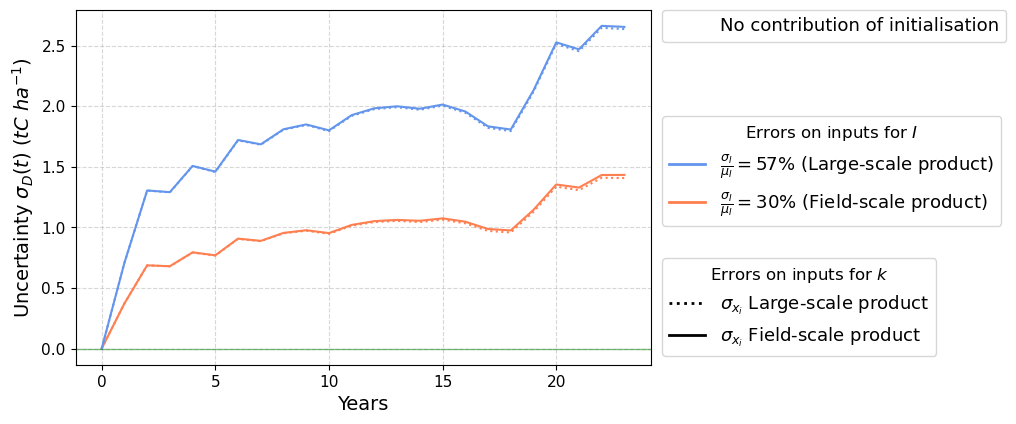

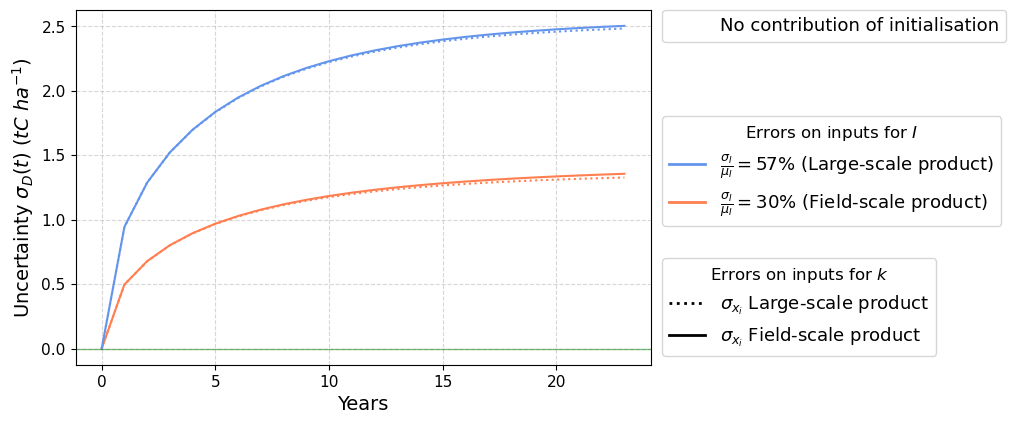

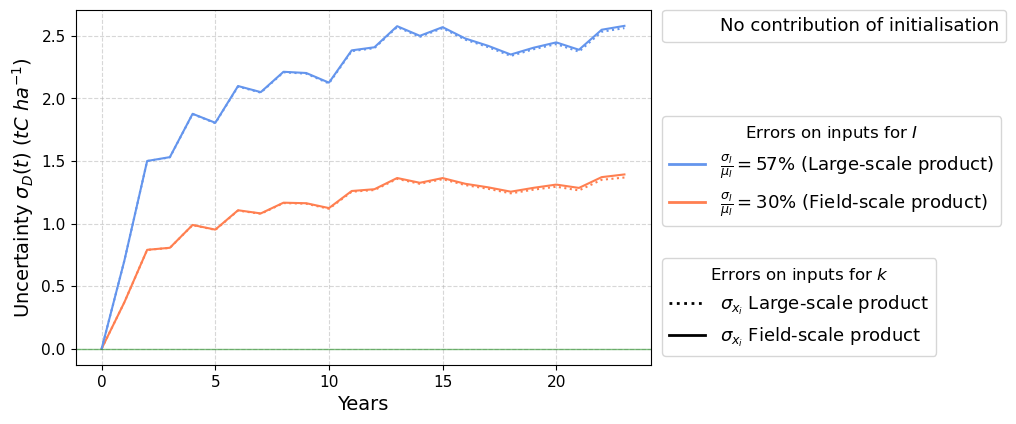

In [45]:
# dictionary that defines the legend namess 
# according to the error scenario configuration 

# for the mineralisation rate :
style_label_map = {
    'kLS':    r'$\sigma_{x_i}} : $ Large-scale product',
    'k10' : r'$\sigma_{x_i}} : $ Field-scale product'
} 
# for the carbon inputs
label_map = {'ACEO':r'$\frac{\sigma_{I}}{\mu_{I}}=30\%$ (Field-scale product)','regstat':r'$\frac{\sigma_{I}}{\mu_{I}}=57\%$ (Large-scale product)'}


# dictionary that defines the color of the curve according to the error scenario configuration to compute intermediate variable uncertainty sigma_I
color_map_dict = {'regstat' : 'cornflowerblue', 'ACEO': 'coral'}

# dictionary that defines the linestyle of the curve according to the error scenario configuration to compute intermediate variable uncertainty sigma_k
style_map_dict = {'k10':'dotted', 'kLS':'solid'}

# directory to save the fig, for now the line savefig is commented in the function
dir_path_figures = '../figures/uncertainty_evolution/carbon_credit/'

# Axis labels
ylabel = r'Uncertainty $\sigma_{D}(t)$ ($tC~ha^{{-1}}$)'


## Call the function to plot

# LEG - Evolution of carbon credit uncertainty for stationary case
plot_sigma(
    sigma_LEG,
    key='stationary',
    dir_path=dir_path_figures,
    title='LEG - Evolution of carbon credit uncertainty for stationary case',
    filename='LEG_carbon_credit_evolution_stationary_uncertainty.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# LEG - Evolution of carbon credit uncertainty for non-stationary case
plot_sigma(
    sigma_LEG,
    key='vari',
    dir_path=dir_path_figures,
    title='LEG - Evolution of carbon credit uncertainty for non-stationary case',
    filename='LEG_carbon_credit_evolution_vari_uncertainty.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# PRO - Evolution of carbon credit uncertainty for stationary case
plot_sigma(
    sigma_PRO,
    key='stationary',
    dir_path=dir_path_figures,
    title='PRO - Evolution of carbon credit uncertainty for stationary case',
    filename='PRO_carbon_credit_evolution_stationary_uncertainty.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# PRO - Evolution of carbon credit uncertainty for non-stationary case
plot_sigma(
    sigma_PRO,
    key='vari',
    dir_path=dir_path_figures,
    title='PRO - Evolution of carbon credit uncertainty for non-stationary case',
    filename='PRO_carbon_credit_evolution_vari_uncertainty.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# Evolution of inferior born $\mu_{D(t)} - z \sigma_{D(t)}$

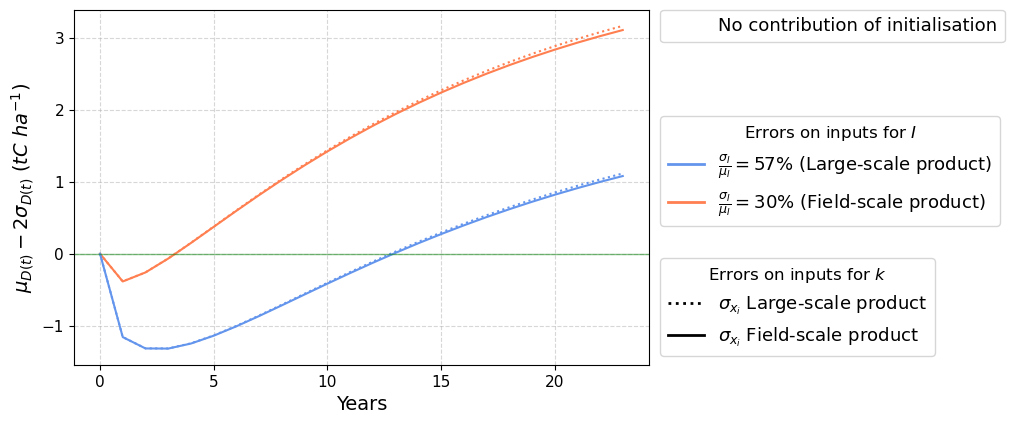

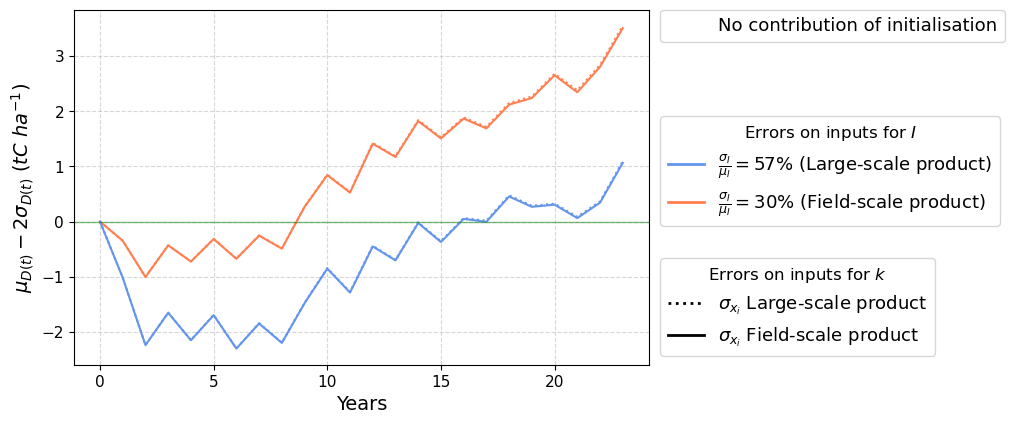

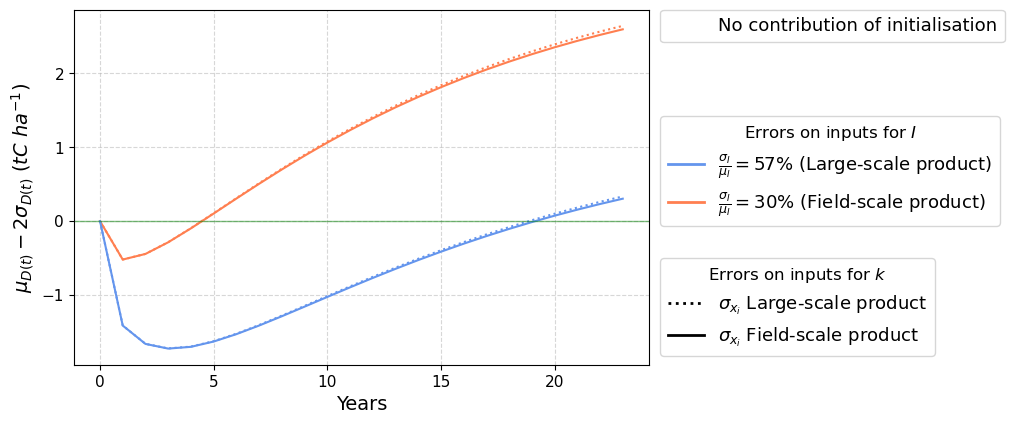

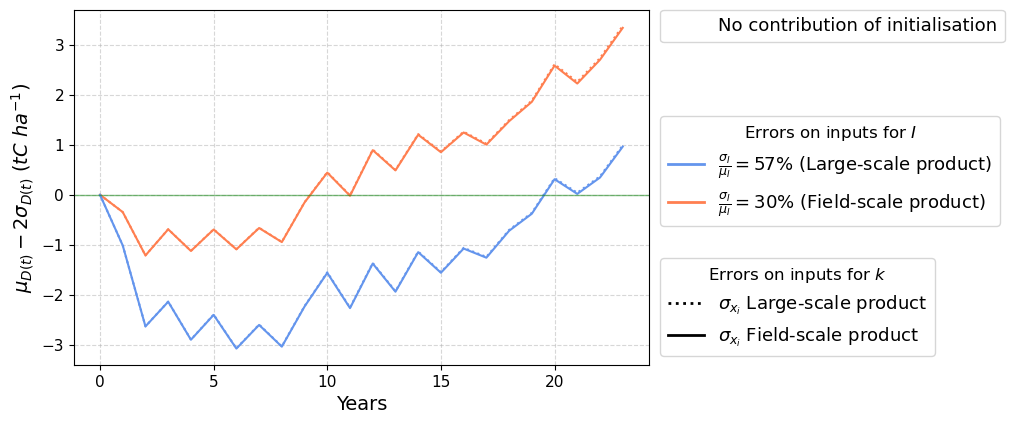

In [46]:
# dictionary that defines the legend namess 
# according to the error scenario configuration 

# for the mineralisation rate :
style_label_map = {
    'kLS':    r'$\sigma_{x_i}} : $ Large-scale product',
    'k10' : r'$\sigma_{x_i}} : $ Field-scale product'
} 
# for the carbon inputs
label_map = {'ACEO':r'$\frac{\sigma_{I}}{\mu_{I}}=30\%$ (Field-scale product)','regstat':r'$\frac{\sigma_{I}}{\mu_{I}}=57\%$ (Large-scale product)'}


# dictionary that defines the color of the curve according to the error scenario configuration to compute intermediate variable uncertainty sigma_I
color_map_dict = {'regstat' : 'cornflowerblue', 'ACEO': 'coral'}

# dictionary that defines the linestyle of the curve according to the error scenario configuration to compute intermediate variable uncertainty sigma_k
style_map_dict = {'k10':'dotted', 'kLS':'solid'}

# directory to save the fig, for now the line savefig is commented in the function
dir_path_figures = '../figures/uncertainty_evolution/carbon_credit/lower_bound_carbon_credit/'



# z, the critical value is defined above in the begining of Application section
ylabel = fr"$\mu_{{D(t)}} - {z} \sigma_{{D(t)}}$ ($tC~ha^{{-1}}$)"

## Call the function to plot

# LEG - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for stationary case',
plot_sigma(
    born_inf_LEG,
    key='stationary',
    dir_path=dir_path_figures,
    title=r'LEG - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for stationary case',
    filename=f'LEG_evolution_stationary_born_inf_uncertainty_IC_{z}.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# LEG - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for non-stationary case',
plot_sigma(
    born_inf_LEG,
    key='vari',
    dir_path=dir_path_figures,
    title=r'LEG - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for non-stationary case',
    filename=f'LEG_evolution_vari_born_inf_uncertainty_IC_{z}.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# PRO - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for stationary case',
plot_sigma(
    born_inf_PRO,
    key='stationary',
    dir_path=dir_path_figures,
    title=r'PRO - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for stationary case',
    filename=f'PRO_evolution_stationary_born_inf_uncertainty_IC_{z}.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)

# PRO - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for non-stationary case',
plot_sigma(
    born_inf_PRO,
    key='vari',
    dir_path=dir_path_figures,
    title=r'PRO - Evolution of $\mu_{D}(t) - 3 \sigma_{D}(t)$ for non-stationary case',
    filename=f'PRO_evolution_vari_born_inf_uncertainty_IC_{z}.png',
    ylabel=ylabel,
    label_map=label_map,
    color_map_dict=color_map_dict,
    style_map_dict=style_map_dict,
    style_label_map=style_label_map
)